In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 

from IPython.core.display import display, HTML
display(HTML("<style>.output_scroll{height: auto !important;}</style>"))

In [3]:
df=pd.read_excel('Ti6Al4V-NiTi单道沉积试样实验观测缺陷类型数据汇总.xlsx',sheet_name='Sheet1')
sample_ids = df.iloc[:, 0].values
df

,试样标号,NiTi粉末材料质量比例,激光功率（W）,移动速度（mm/min）,归一化线质量,激光能量密度（J/mm2）,熔池宽度（μm）,熔池深度（μm）,沉积宽度（μm）,沉积高度（μm）,左润湿角（°）,右润湿角（°）,缺陷类型,熔合不良、气孔、球化=0_理想工艺=1_裂纹=2
0,A-1,0.0,600,200,1.000000,90.000000,2803.604,836.036,2075.6760,1762.162,131.315,99.836,熔合不良、气孔,0
1,A-2,0.0,700,200,1.000000,105.000000,3189.189,908.108,2428.8290,1751.351,109.671,91.650,气孔,0
2,A-3,0.0,800,200,1.000000,120.000000,3654.054,1001.802,2900.9010,1888.288,104.036,87.592,气孔,0
3,A-4,0.0,900,200,1.000000,135.000000,4075.676,1095.495,3189.1890,1780.180,92.068,98.973,气孔,0
4,A-5,0.0,600,250,0.600000,72.000000,2661.111,807.477,1824.0740,1659.259,138.094,134.676,气孔,0
5,A-6,0.0,700,250,0.600000,84.000000,3124.074,914.815,2301.8520,1648.148,132.679,112.818,气孔,0
6,A-7,0.0,800,250,0.600000,96.000000,3549.550,936.937,2724.3240,1517.117,99.851,85.486,气孔,0
7,A-8,0.0,900,250,0.600000,108.000000,3960.360,1045.045,3099.0990,1513.514,70.434,87.241,气孔,0
8,A-9,0.0,600,300,0.333333,60.000000,2631.776,798.131,2016.8220,1343.925,85.851,128.480,球化、气孔,0
9,A-10,0.0,700,300,0.333333,70.000000,3018.692,829.907,2366.3550,1338.486,96.607,81.174,气孔,0


In [4]:
df = df.drop(df.columns[[0, 12]], axis=1)
df

,NiTi粉末材料质量比例,激光功率（W）,移动速度（mm/min）,归一化线质量,激光能量密度（J/mm2）,熔池宽度（μm）,熔池深度（μm）,沉积宽度（μm）,沉积高度（μm）,左润湿角（°）,右润湿角（°）,熔合不良、气孔、球化=0_理想工艺=1_裂纹=2
0,0.0,600,200,1.000000,90.000000,2803.604,836.036,2075.6760,1762.162,131.315,99.836,0
1,0.0,700,200,1.000000,105.000000,3189.189,908.108,2428.8290,1751.351,109.671,91.650,0
2,0.0,800,200,1.000000,120.000000,3654.054,1001.802,2900.9010,1888.288,104.036,87.592,0
3,0.0,900,200,1.000000,135.000000,4075.676,1095.495,3189.1890,1780.180,92.068,98.973,0
4,0.0,600,250,0.600000,72.000000,2661.111,807.477,1824.0740,1659.259,138.094,134.676,0
5,0.0,700,250,0.600000,84.000000,3124.074,914.815,2301.8520,1648.148,132.679,112.818,0
6,0.0,800,250,0.600000,96.000000,3549.550,936.937,2724.3240,1517.117,99.851,85.486,0
7,0.0,900,250,0.600000,108.000000,3960.360,1045.045,3099.0990,1513.514,70.434,87.241,0
8,0.0,600,300,0.333333,60.000000,2631.776,798.131,2016.8220,1343.925,85.851,128.480,0
9,0.0,700,300,0.333333,70.000000,3018.692,829.907,2366.3550,1338.486,96.607,81.174,0


In [5]:
value_counts = df.iloc[:, -1].value_counts()
print(value_counts)

熔合不良、气孔、球化=0_理想工艺=1_裂纹=2
0    46
2    41
1    33
Name: count, dtype: int64


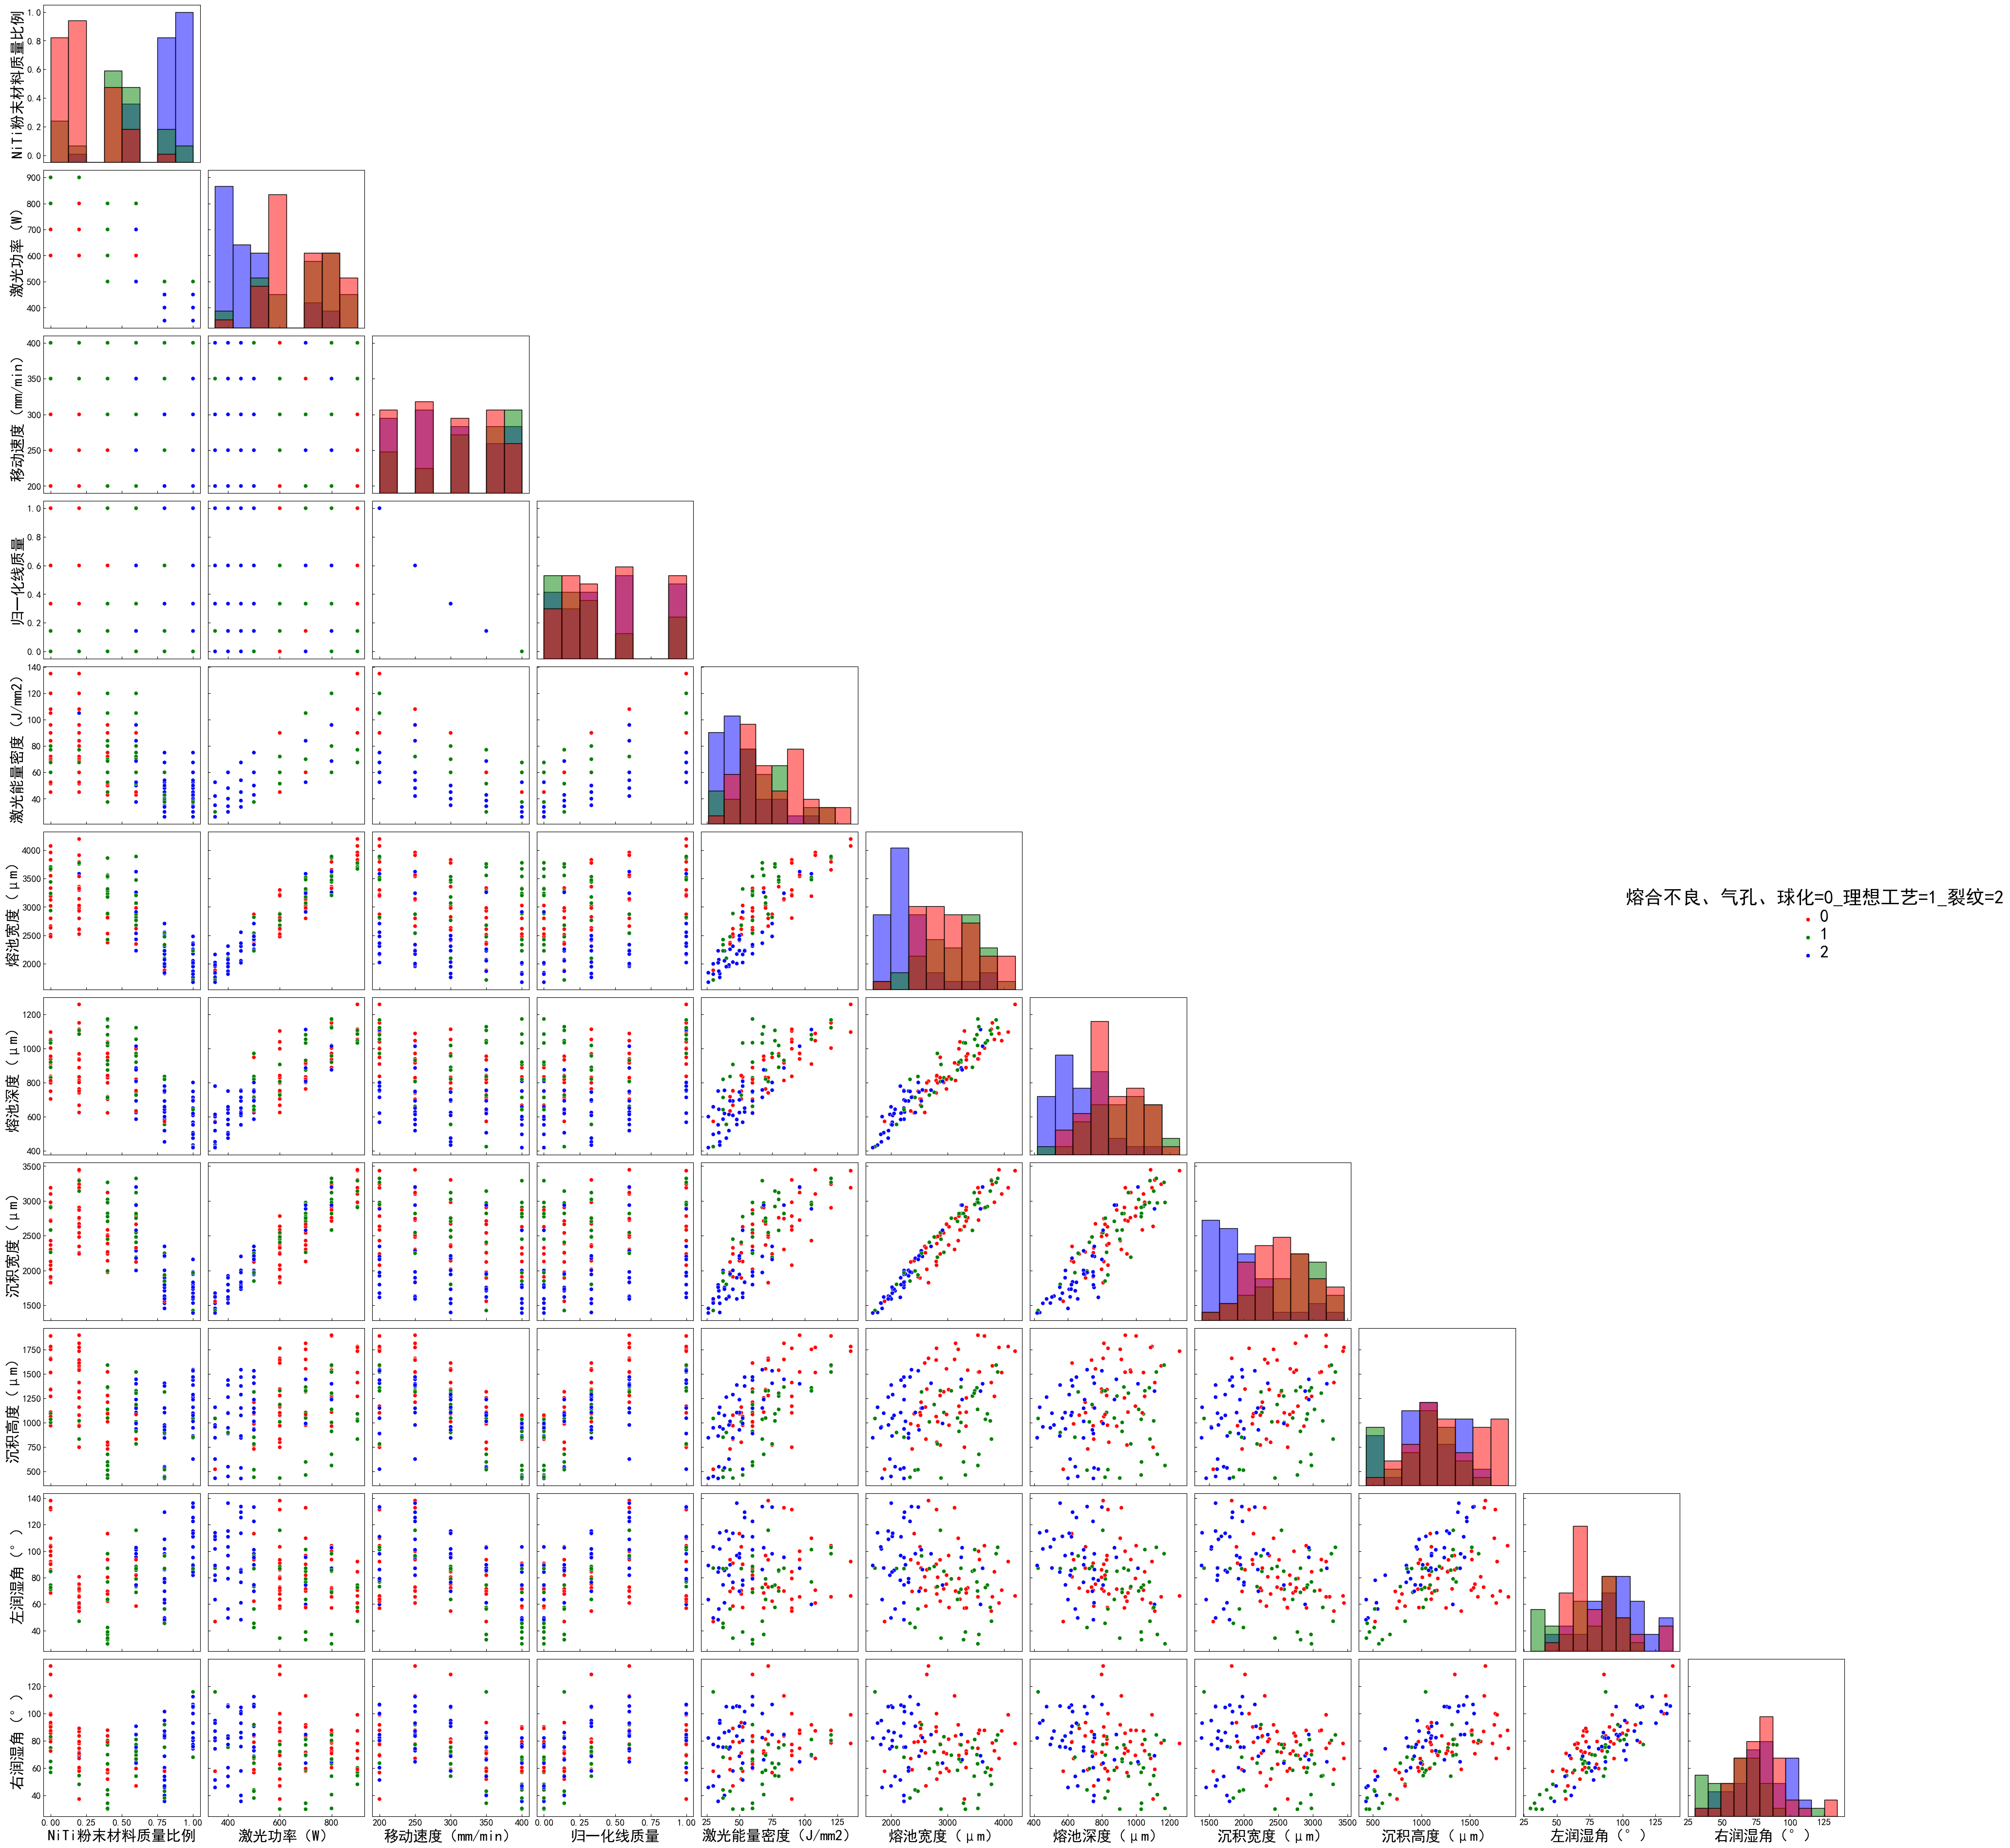

In [6]:
target_column = df.columns[-1]
palette = {0: 'red', 1: 'green', 2: 'blue'}

figure = sns.pairplot(df, hue=target_column, palette=palette, diag_kind='hist', height=3.5)

for ax in figure.axes.flatten():
    ax.tick_params(axis='both', which='major', labelsize=14)  
    ax.xaxis.label.set_size(22)  
    ax.yaxis.label.set_size(22)  


for ax in figure.axes.flatten():
    ax.tick_params(axis='both', which='both', direction='in')  
    ax.spines['top'].set_visible(True) 
    ax.spines['right'].set_visible(True) 

for i, j in zip(*np.triu_indices_from(figure.axes, 1)): 
    figure.axes[i, j].set_visible(False) 
    
# for i, j in zip(*np.tril_indices_from(figure.axes, -1)): 
#     figure.axes[i, j].set_visible(False)

figure.fig.subplots_adjust(wspace=0.05, hspace=0.05)

if figure._legend is not None:  
    for text in figure._legend.texts:  
        text.set_fontsize(26)
    figure._legend.get_title().set_fontsize(28)  
    
plt.show()

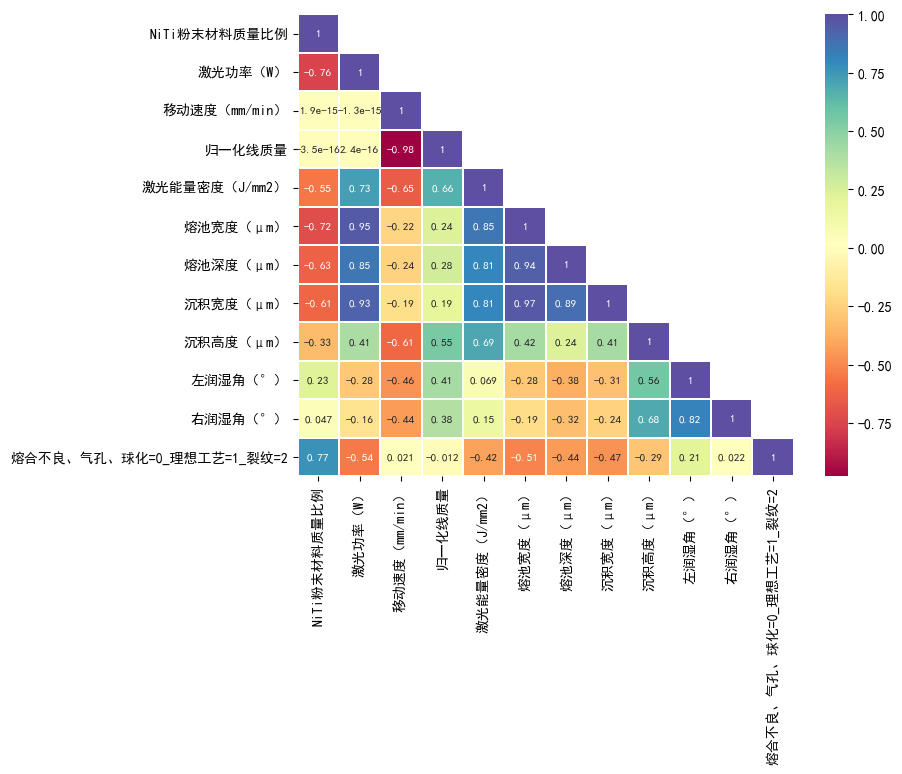

In [7]:
corr = df.corr()
mask = np.tril(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(8, 6))
sns.heatmap(corr, mask=~mask, annot=True, linewidths=0.1, annot_kws={"size": 8}, linecolor='white', cmap='Spectral')
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
X_train, X_test, y_train, y_test, sample_ids_train, sample_ids_test = train_test_split(X, y, sample_ids, 
                                                                                       test_size=1./12, 
                                                                                       shuffle=True, 
                                                                                       random_state=10, 
                                                                                       stratify=y)

In [9]:
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.multiclass import OneVsRestClassifier
from itertools import cycle

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
models = {
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=10, n_estimators=100, max_depth=6, 
                             learning_rate=0.1, subsample=0.8, colsample_bytree=0.8),
    'Random Forest': RandomForestClassifier(random_state=10, n_estimators=100, max_depth=None, max_features='sqrt'),
    'Logistic Regression': LogisticRegression(random_state=10, max_iter=1000, penalty='l2', solver='liblinear'),
    'Support Vector Machine': SVC(random_state=10, C=1.0, kernel='rbf', gamma='scale', probability=True),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(32, 64, 128), max_iter=100000,  random_state=10, activation='relu', 
                                    solver='adam', alpha=0.0001),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='minkowski', p=2)
}

results = {}
error_analysis = {}

for name, model in models.items():
    if name in ['Logistic Regression', 'Support Vector Machine', 'Neural Network', 'K-Nearest Neighbors']:
        model.fit(X_train_scaled, y_train)  
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)  
        y_pred = model.predict(X_test)
    

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted') 
    class_report = classification_report(y_test, y_pred, target_names=['熔合不良、气孔、球化', '理想工艺', '裂纹'])
    conf_matrix = confusion_matrix(y_test, y_pred)
    
    results[name] = {'model': model,
                     'accuracy': accuracy,
                     'f1_score': f1,
                     'classification_report': class_report,
                     'confusion_matrix': conf_matrix}
    

    print(f'Model: {name}')
    print(f'Accuracy: {accuracy:.4f}')
    print(f'F1-Score: {f1:.4f}')
    print('Classification Report:')
    print(class_report)
    
    assert len(sample_ids_test) == len(y_test), 'Sample IDs and y_test do not match in size!'
    
    error_info = {
        'Sample ID': sample_ids_test[(y_pred != y_test).values],
        'Actual Value': y_test.iloc[(y_pred != y_test).values],
        'Predicted Value': y_pred[(y_pred != y_test).values]
    }
    error_analysis[name] = pd.DataFrame(error_info)  

    print(f'\nModel: {name}')
    print(f"umber of Errors: {len(error_info['Sample ID'])}")
    print(error_analysis[name])
    print('-' * 75)

Model: XGBoost
Accuracy: 0.8000
F1-Score: 0.8000
Classification Report:
              precision    recall  f1-score   support

  熔合不良、气孔、球化       0.75      0.75      0.75         4
        理想工艺       0.67      0.67      0.67         3
          裂纹       1.00      1.00      1.00         3

    accuracy                           0.80        10
   macro avg       0.81      0.81      0.81        10
weighted avg       0.80      0.80      0.80        10


Model: XGBoost
umber of Errors: 2
   Sample ID  Actual Value  Predicted Value
42       C-3             1                0
20       B-1             0                1
---------------------------------------------------------------------------
Model: Random Forest
Accuracy: 0.9000
F1-Score: 0.9000
Classification Report:
              precision    recall  f1-score   support

  熔合不良、气孔、球化       1.00      0.75      0.86         4
        理想工艺       0.75      1.00      0.86         3
          裂纹       1.00      1.00      1.00         3

    accu

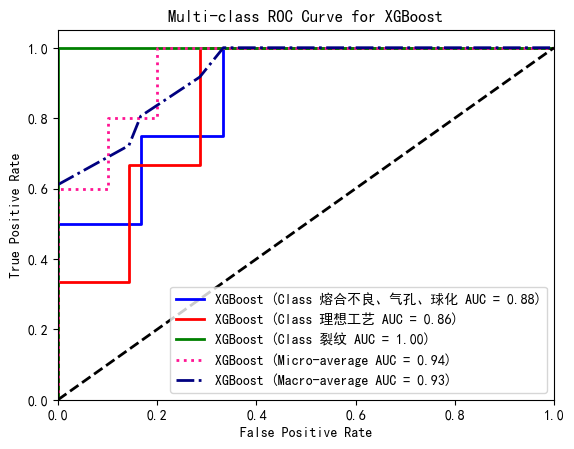

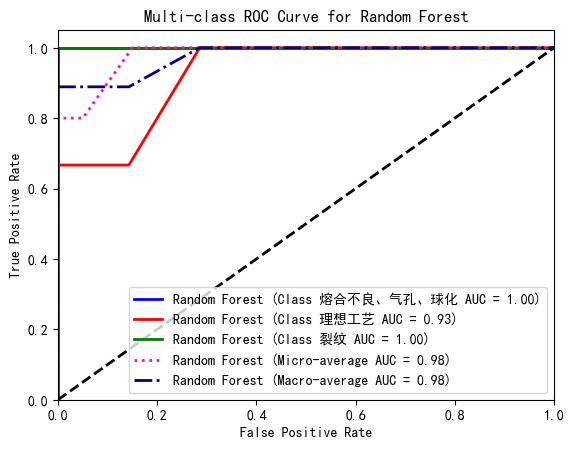

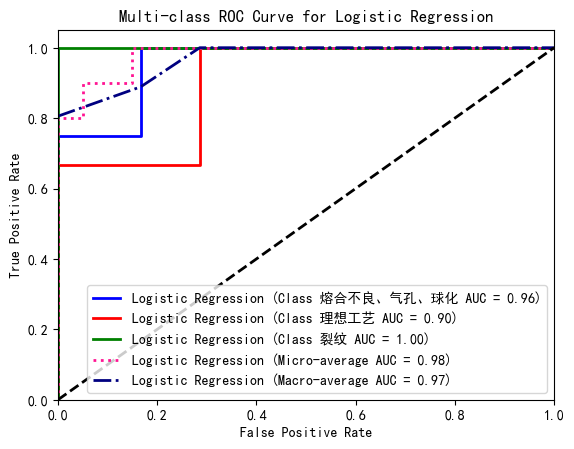

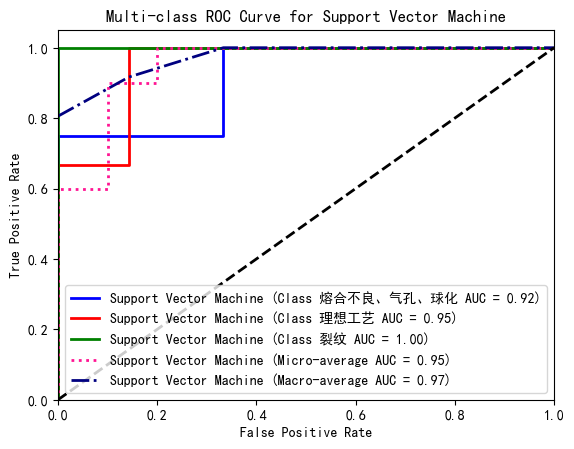

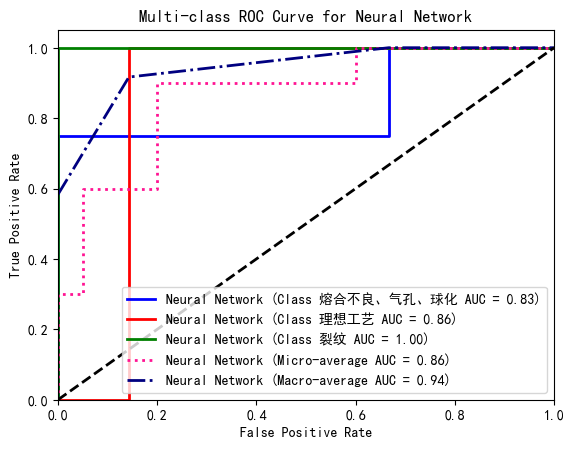

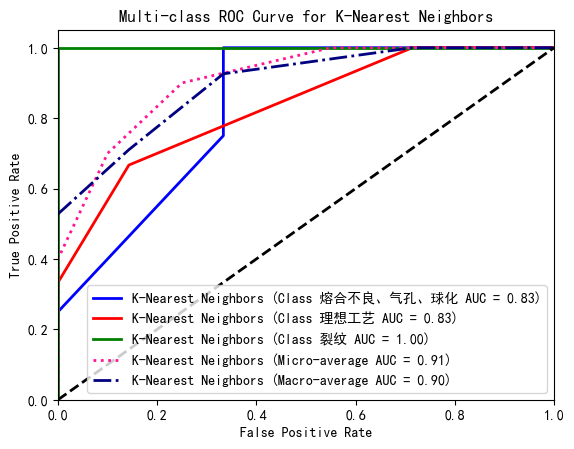

In [12]:
classes = ['熔合不良、气孔、球化', '理想工艺', '裂纹']
n_classes = len(classes)

for name, model in models.items():
    if name in ['Logistic Regression', 'Support Vector Machine', 'Neural Network', 'K-Nearest Neighbors']:
        y_pred_prob = model.predict_proba(X_test_scaled)  
    else:
        y_pred_prob = model.predict_proba(X_test)  

    fpr = {}
    tpr = {}
    roc_auc = {}

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve((y_test == i).astype(int), y_pred_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    fpr['micro'], tpr['micro'], _ = roc_curve((y_test.to_numpy().reshape(-1, 1) == np.arange(n_classes)).ravel(),y_pred_prob.ravel())
    roc_auc['micro'] = auc(fpr['micro'], tpr['micro'])

    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    fpr['macro'] = all_fpr
    tpr['macro'] = mean_tpr
    roc_auc['macro'] = auc(fpr['macro'], tpr['macro'])

    colors = cycle(['blue', 'red', 'green'])
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'{name} (Class {classes[i]} AUC = {roc_auc[i]:.2f})')

    plt.plot(fpr['micro'], tpr['micro'], color='deeppink', linestyle=':', linewidth=2, 
             label=f"{name} (Micro-average AUC = {roc_auc['micro']:.2f})")

    plt.plot(fpr['macro'], tpr['macro'], color='navy', linestyle='-.', linewidth=2,
             label=f"{name} (Macro-average AUC = {roc_auc['macro']:.2f})")

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Multi-class ROC Curve for {name}')
    plt.legend(loc='lower right')
    plt.show()

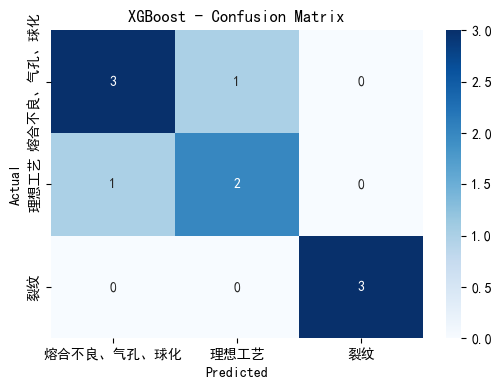

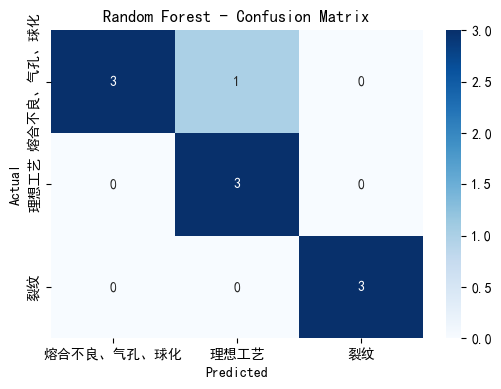

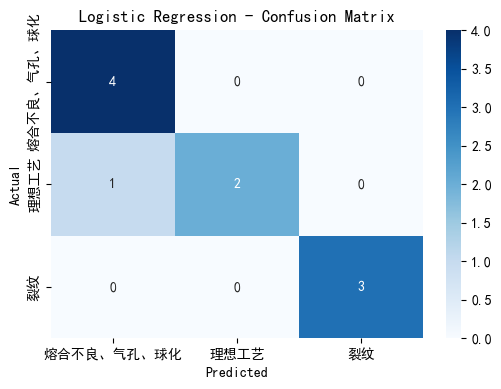

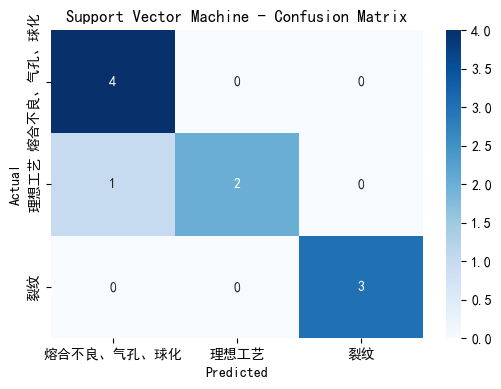

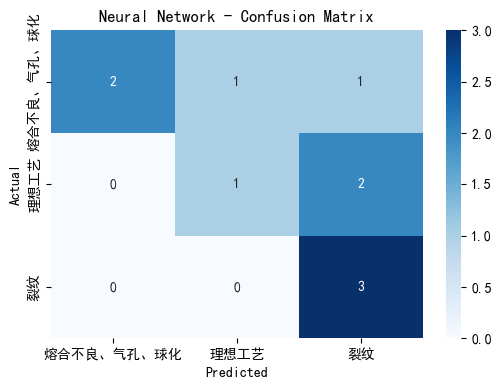

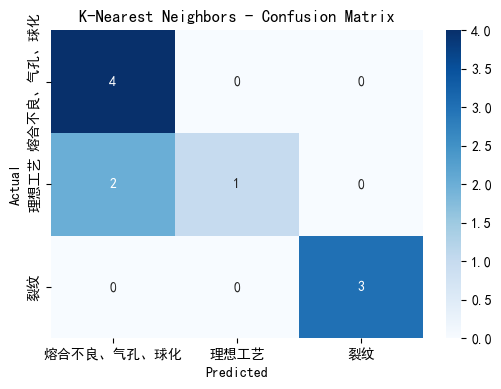

In [13]:
for name, result in results.items():
    conf_matrix = result['confusion_matrix']
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['熔合不良、气孔、球化', '理想工艺', '裂纹'], yticklabels=['熔合不良、气孔、球化', '理想工艺', '裂纹'])
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

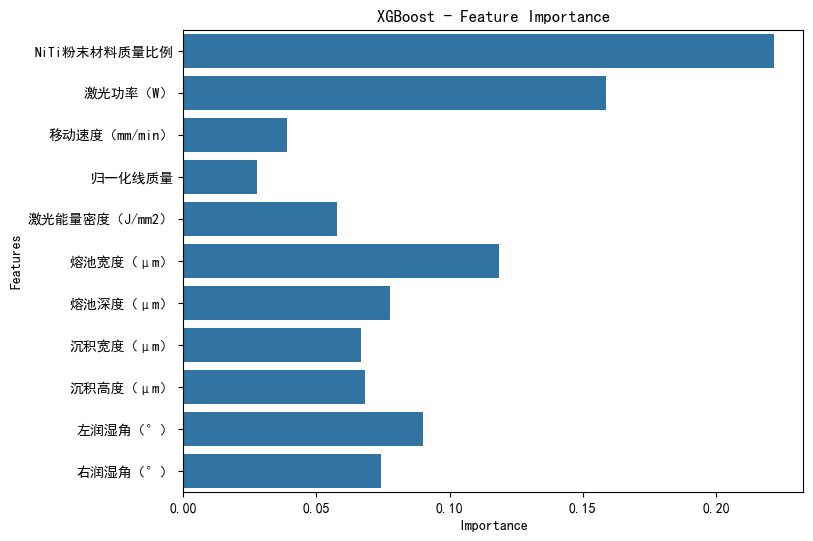

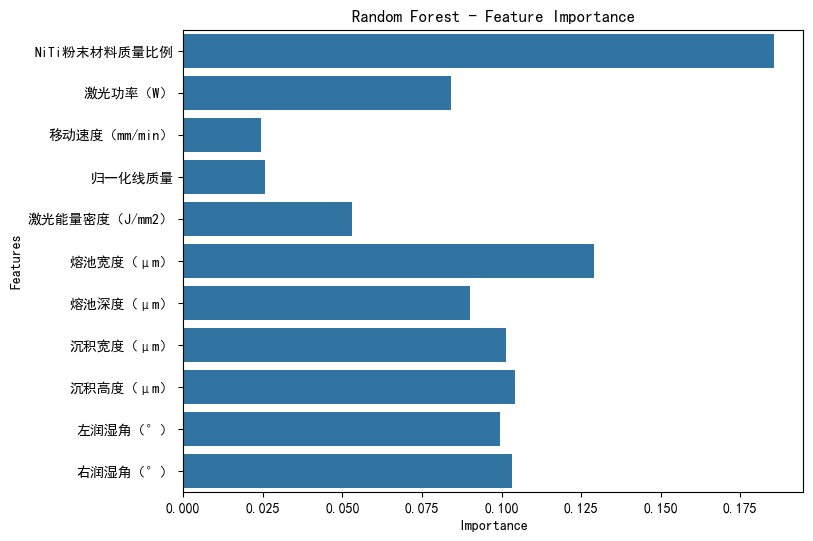

In [14]:
for name in ['XGBoost', 'Random Forest']:
    model = results[name]['model']
    importance = model.feature_importances_
    
    plt.figure(figsize=(8, 6))
    feature_names = X.columns
    sns.barplot(x=importance, y=feature_names)
    plt.title(f'{name} - Feature Importance')
    plt.xlabel('Importance')
    plt.ylabel('Features')
    plt.show()

In [15]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

def model_with_random_search(X, y, model, param_dist, scoring='accuracy', cv_splits=11, n_iter=5000):
   
    stratified_kfold = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=10)

    random_search = RandomizedSearchCV(estimator=model, param_distributions=param_dist, n_iter=n_iter, 
                                     cv= stratified_kfold, scoring=scoring, random_state=10, n_jobs=-1, verbose=1)

    random_search.fit(X, y)

    print('最优超参数:', random_search.best_params_)
    print('最佳超参数下的准确率:', random_search.best_score_)

    return random_search.best_estimator_

Fitting 11 folds for each of 5000 candidates, totalling 55000 fits
最优超参数: {'subsample': 0.7, 'n_estimators': 50, 'min_child_weight': 1, 'max_depth': 1, 'learning_rate': 0.6, 'gamma': 5, 'colsample_bytree': 0.9}
最佳超参数下的准确率: 0.7454545454545456
最佳模型在测试数据上的准确率: 0.8000
F1-Score: 0.77


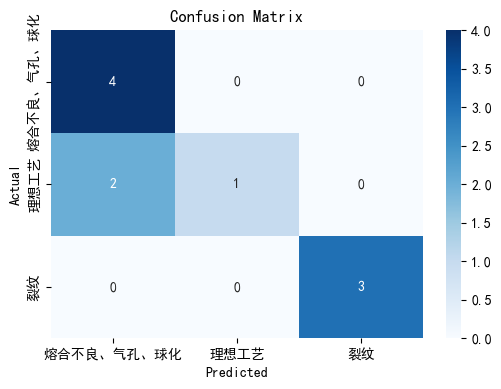

In [16]:
xgb_model = XGBClassifier(booster='gbtree',objective='multi:softprob', random_state=10, use_label_encoder=False, eval_metric='logloss')

param_dist = {
    'n_estimators': [10, 25, 50, 75, 100, 150, 200],
    'gamma':[0, 0.1, 0.25, 0.5, 0.75, 1, 2, 5],
    'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9],
    'learning_rate': [0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
    'min_child_weight':[1, 2, 3, 4, 5, 6],
    'subsample': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
}

best_model = model_with_random_search(X_train, y_train, model=xgb_model, param_dist=param_dist)

y_pred = best_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
print(f'最佳模型在测试数据上的准确率: {test_accuracy:.4f}')
f1 = f1_score(y_test, y_pred, average='weighted') 
print('F1-Score:', f1)

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['熔合不良、气孔、球化', '理想工艺', '裂纹'], yticklabels=['熔合不良、气孔、球化', '理想工艺', '裂纹'])
plt.title(f'Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

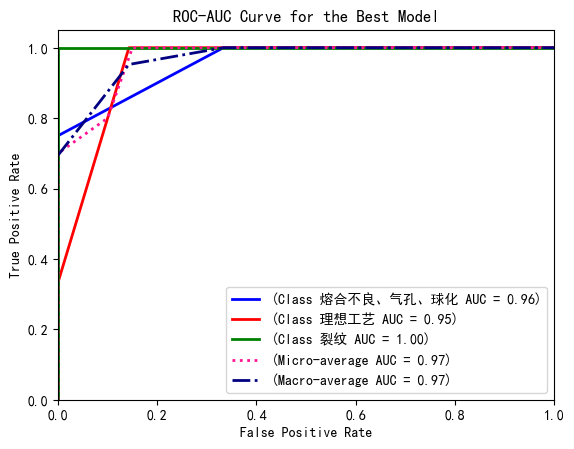

In [17]:
y_pred_prob = best_model.predict_proba(X_test)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve((y_test == i).astype(int), y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr['micro'], tpr['micro'], _ = roc_curve((y_test.to_numpy().reshape(-1, 1) == np.arange(n_classes)).ravel(),y_pred_prob.ravel())
roc_auc['micro'] = auc(fpr['micro'], tpr['micro'])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr['macro'] = all_fpr
tpr['macro'] = mean_tpr
roc_auc['macro'] = auc(fpr['macro'], tpr['macro'])

colors = cycle(['blue', 'red', 'green'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'(Class {classes[i]} AUC = {roc_auc[i]:.2f})')

plt.plot(fpr['micro'], tpr['micro'], color='deeppink', linestyle=':', linewidth=2, 
         label=f"(Micro-average AUC = {roc_auc['micro']:.2f})")

plt.plot(fpr['macro'], tpr['macro'], color='navy', linestyle='-.', linewidth=2,
         label=f"(Macro-average AUC = {roc_auc['macro']:.2f})")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve for the Best Model')
plt.legend(loc='lower right')
plt.show()

Fitting 11 folds for each of 5000 candidates, totalling 55000 fits
最优超参数: {'updater': 'coord_descent', 'top_k': 5, 'reg_lambda': 0, 'reg_alpha': 0, 'n_estimators': 200, 'learning_rate': 0.3, 'feature_selector': 'cyclic'}
最佳超参数下的准确率: 0.7363636363636364
最佳模型在测试数据上的准确率: 0.8000
F1-Score: 0.8


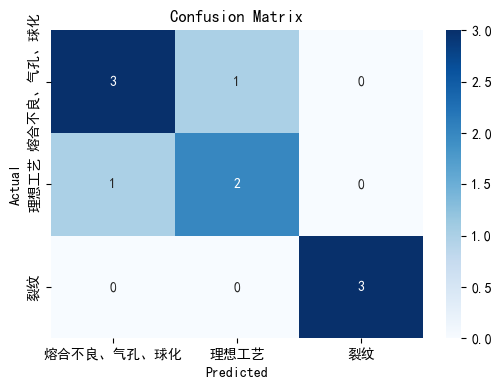

In [18]:
xgb_model = XGBClassifier(booster='gblinear',objective='multi:softprob', random_state=10, use_label_encoder=False, eval_metric='logloss')

param_dist = {
    'n_estimators': [25, 50, 100, 150, 200, 250, 300],  
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3, 0.5], 
    'reg_lambda': [0, 0.01, 0.1, 0.5, 1, 5, 10],
    'reg_alpha': [0, 0.01, 0.1, 0.5, 1, 5, 10], 
    'updater': ['shotgun', 'coord_descent'],
    'feature_selector': ['cyclic', 'shuffle', 'random', 'greedy', 'thrifty'],
    'top_k': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] 
}

best_model = model_with_random_search(X_train, y_train, model=xgb_model, param_dist=param_dist)

y_pred = best_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
print(f'最佳模型在测试数据上的准确率: {test_accuracy:.4f}')
f1 = f1_score(y_test, y_pred, average='weighted') 
print('F1-Score:', f1)

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['熔合不良、气孔、球化', '理想工艺', '裂纹'], yticklabels=['熔合不良、气孔、球化', '理想工艺', '裂纹'])
plt.title(f'Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

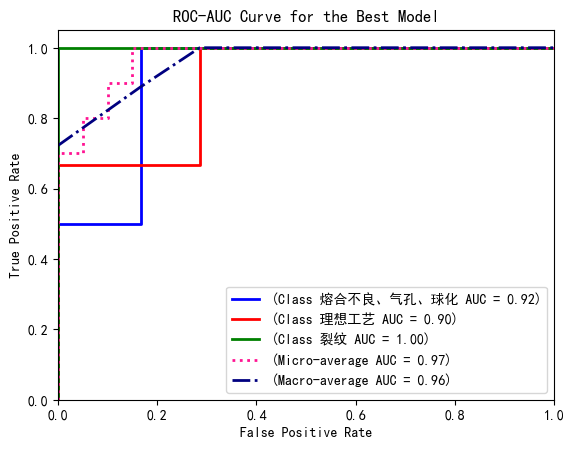

In [19]:
y_pred_prob = best_model.predict_proba(X_test)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve((y_test == i).astype(int), y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr['micro'], tpr['micro'], _ = roc_curve((y_test.to_numpy().reshape(-1, 1) == np.arange(n_classes)).ravel(),y_pred_prob.ravel())
roc_auc['micro'] = auc(fpr['micro'], tpr['micro'])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr['macro'] = all_fpr
tpr['macro'] = mean_tpr
roc_auc['macro'] = auc(fpr['macro'], tpr['macro'])

colors = cycle(['blue', 'red', 'green'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'(Class {classes[i]} AUC = {roc_auc[i]:.2f})')

plt.plot(fpr['micro'], tpr['micro'], color='deeppink', linestyle=':', linewidth=2, 
         label=f"(Micro-average AUC = {roc_auc['micro']:.2f})")

plt.plot(fpr['macro'], tpr['macro'], color='navy', linestyle='-.', linewidth=2,
         label=f"(Macro-average AUC = {roc_auc['macro']:.2f})")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve for the Best Model')
plt.legend(loc='lower right')
plt.show()

Fitting 11 folds for each of 5000 candidates, totalling 55000 fits
最优超参数: {'subsample': 0.6, 'skip_drop': 0.0, 'sample_type': 'uniform', 'rate_drop': 0.3, 'normalize_type': 'forest', 'n_estimators': 250, 'min_child_weight': 3, 'max_depth': 1, 'learning_rate': 0.3, 'colsample_bytree': 0.9}
最佳超参数下的准确率: 0.7454545454545454
最佳模型在测试数据上的准确率: 0.9000
F1-Score: 0.9


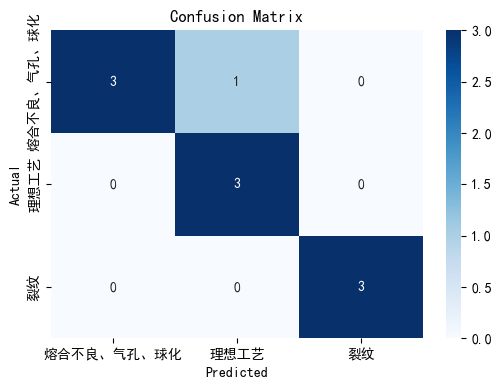

In [20]:
xgb_model = XGBClassifier(booster='dart',objective='multi:softprob', random_state=10, use_label_encoder=False, eval_metric='logloss')

param_dist = {
    'n_estimators': [10, 25, 50, 75, 100, 150, 200, 250, 300], 
    'learning_rate': [0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6], 
    'max_depth': [1, 2, 3, 4, 5, 6, 7, 8], 
    'min_child_weight': [1, 2, 3, 4, 5], 
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0], 
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],  
    'rate_drop': [0.0, 0.1, 0.2, 0.3, 0.4],  
    'skip_drop': [0.0, 0.1, 0.2, 0.3, 0.4],  
    'sample_type': ['uniform', 'weighted'],  
    'normalize_type': ['tree', 'forest'] 
}

best_model = model_with_random_search(X_train, y_train, model=xgb_model, param_dist=param_dist)

y_pred = best_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
print(f'最佳模型在测试数据上的准确率: {test_accuracy:.4f}')
f1 = f1_score(y_test, y_pred, average='weighted') 
print('F1-Score:', f1)

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['熔合不良、气孔、球化', '理想工艺', '裂纹'], yticklabels=['熔合不良、气孔、球化', '理想工艺', '裂纹'])
plt.title(f'Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

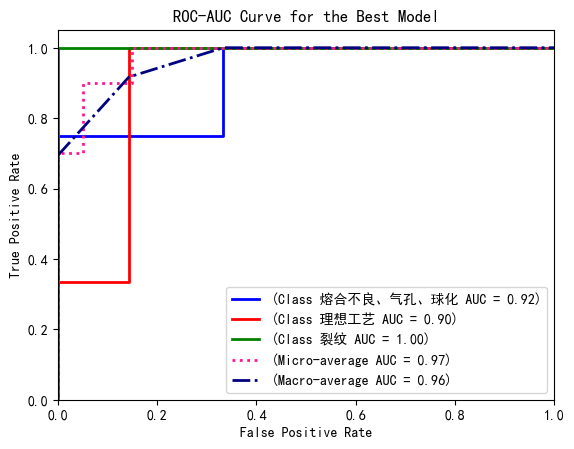

In [21]:
y_pred_prob = best_model.predict_proba(X_test)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve((y_test == i).astype(int), y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr['micro'], tpr['micro'], _ = roc_curve((y_test.to_numpy().reshape(-1, 1) == np.arange(n_classes)).ravel(),y_pred_prob.ravel())
roc_auc['micro'] = auc(fpr['micro'], tpr['micro'])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr['macro'] = all_fpr
tpr['macro'] = mean_tpr
roc_auc['macro'] = auc(fpr['macro'], tpr['macro'])

colors = cycle(['blue', 'red', 'green'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'(Class {classes[i]} AUC = {roc_auc[i]:.2f})')

plt.plot(fpr['micro'], tpr['micro'], color='deeppink', linestyle=':', linewidth=2, 
         label=f"(Micro-average AUC = {roc_auc['micro']:.2f})")

plt.plot(fpr['macro'], tpr['macro'], color='navy', linestyle='-.', linewidth=2,
         label=f"(Macro-average AUC = {roc_auc['macro']:.2f})")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve for the Best Model')
plt.legend(loc='lower right')
plt.show()